# Task 1 – Audio Preprocessing and Visualization

## Objective
Load an audio sample, apply preprocessing techniques, and compare the original and processed audio using multiple visualizations:
- Waveform
- Mel Spectrogram
- MFCC Heatmap
- FFT Spectrum

Dataset Used:
- LibriSpeech (sample audio)

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
audio_path = librosa.ex("libri1")

audio, sr = librosa.load(audio_path, sr=None)

print("Sample Rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

Sample Rate: 22050
Duration: 14.84 seconds


## Audio Preprocessing

The following preprocessing steps are performed:

- Resampling to 16 kHz
- Amplitude Normalization
- Silence Trimming

In [3]:
# Resample
audio_resampled = librosa.resample(audio, orig_sr=sr, target_sr=16000)

# Normalize
audio_normalized = librosa.util.normalize(audio_resampled)

# Trim silence
audio_processed, _ = librosa.effects.trim(audio_normalized)

new_sr = 16000

print("Processed Duration:", len(audio_processed)/new_sr, "seconds")

Processed Duration: 14.808 seconds


## Waveform Comparison

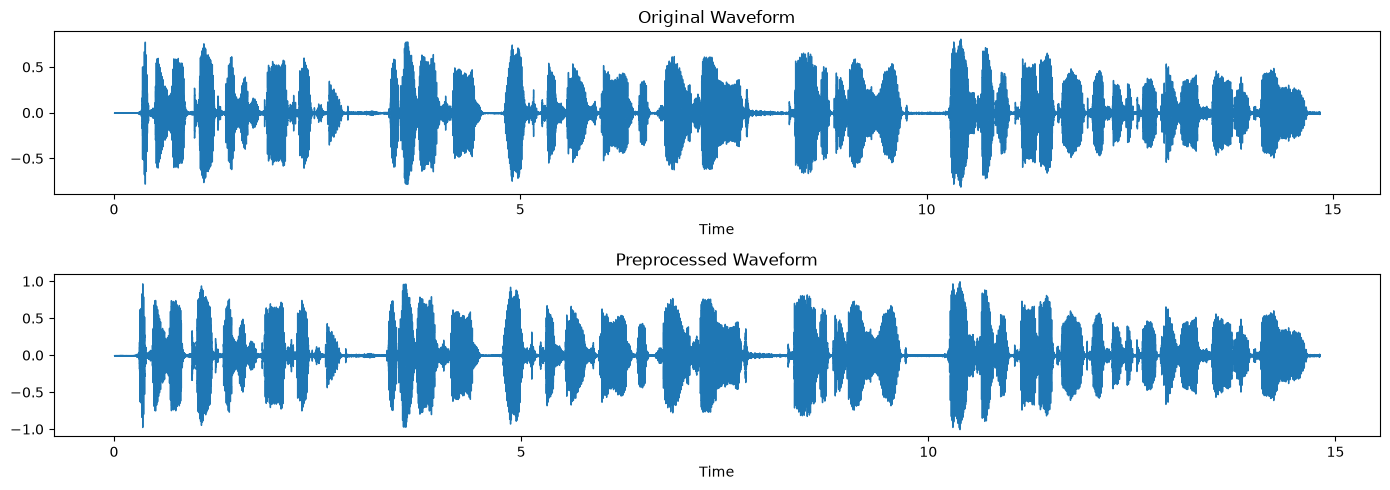

In [5]:
plt.figure(figsize=(14,5))

plt.subplot(2,1,1)
librosa.display.waveshow(audio, sr=sr)
plt.title("Original Waveform")

plt.subplot(2,1,2)
librosa.display.waveshow(audio_processed, sr=new_sr)
plt.title("Preprocessed Waveform")

plt.tight_layout()
plt.show()

## Mel Spectrogram Comparison

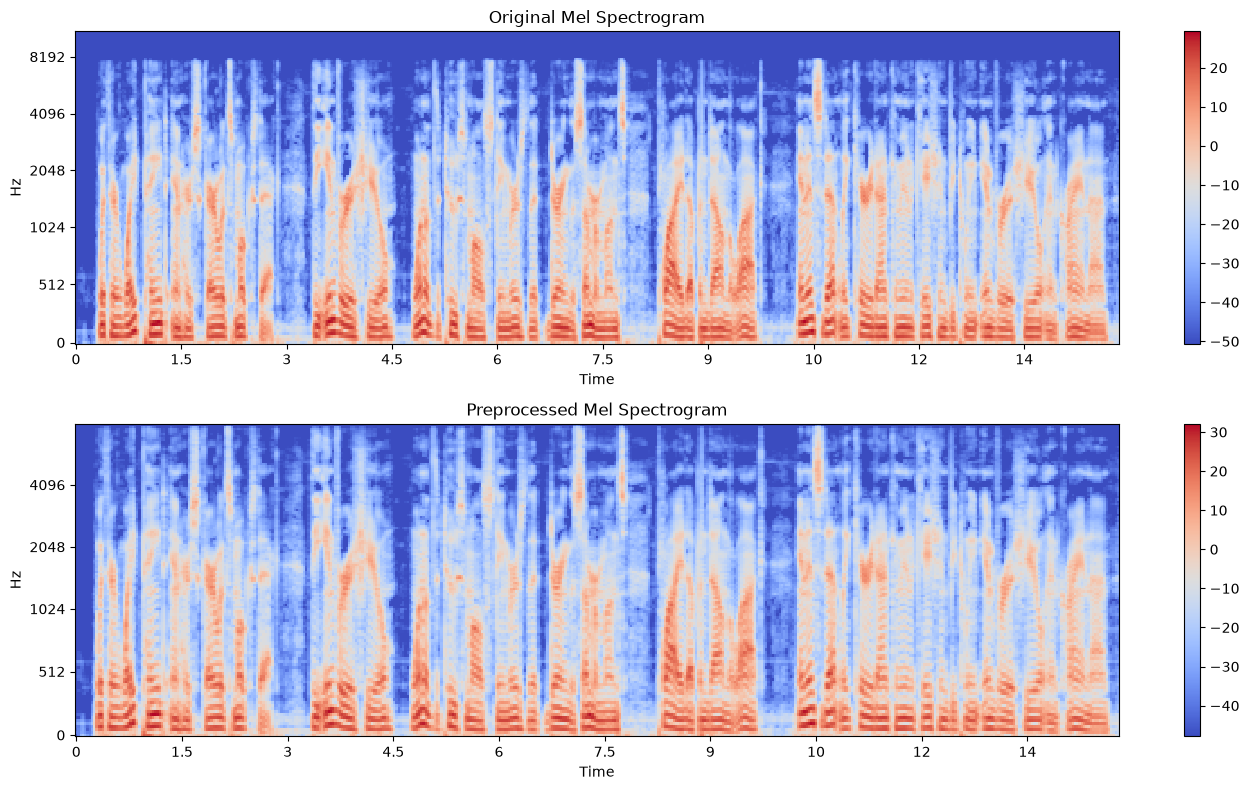

In [6]:
mel_original = librosa.feature.melspectrogram(y=audio, sr=sr)
mel_processed = librosa.feature.melspectrogram(y=audio_processed, sr=new_sr)

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
librosa.display.specshow(
    librosa.power_to_db(mel_original),
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.title("Original Mel Spectrogram")
plt.colorbar()

plt.subplot(2,1,2)
librosa.display.specshow(
    librosa.power_to_db(mel_processed),
    sr=new_sr,
    x_axis='time',
    y_axis='mel'
)
plt.title("Preprocessed Mel Spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()

## MFCC Heatmap Comparison

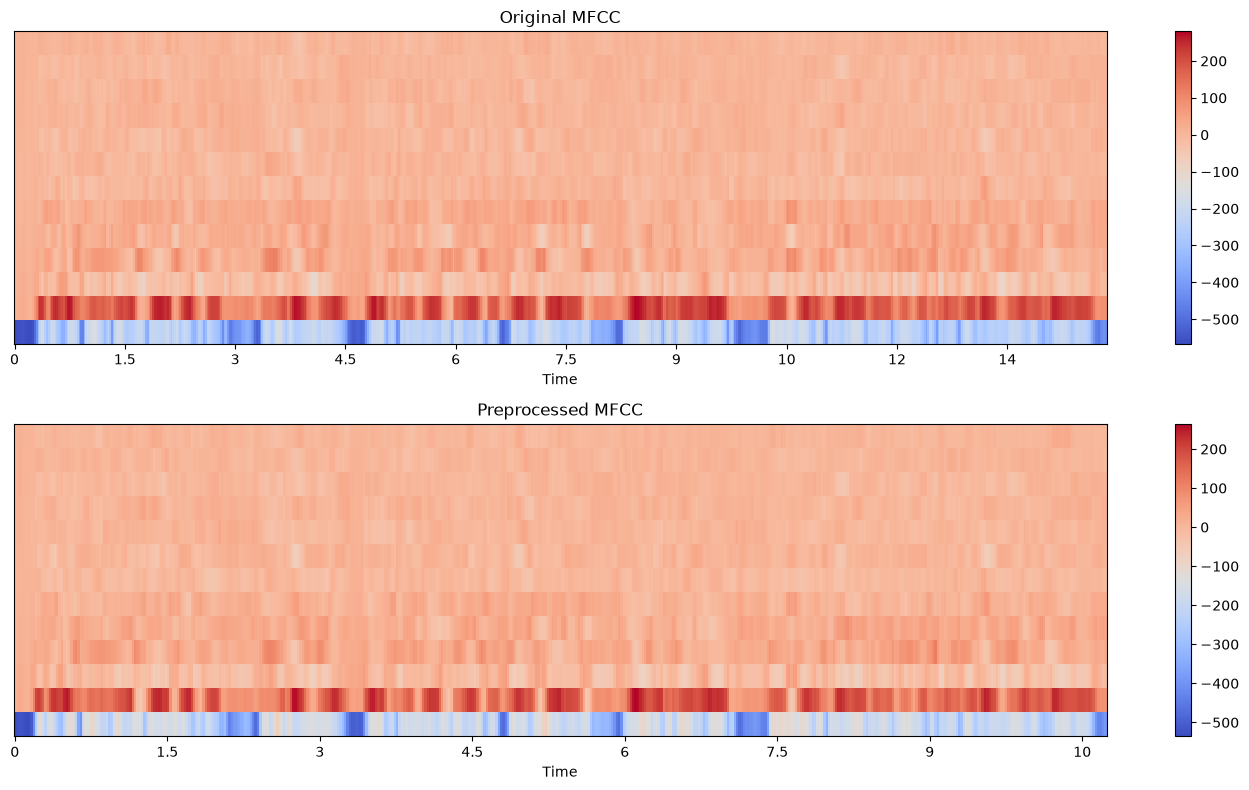

In [7]:
mfcc_original = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
mfcc_processed = librosa.feature.mfcc(y=audio_processed, sr=new_sr, n_mfcc=13)

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
librosa.display.specshow(mfcc_original, x_axis='time')
plt.title("Original MFCC")
plt.colorbar()

plt.subplot(2,1,2)
librosa.display.specshow(mfcc_processed, x_axis='time')
plt.title("Preprocessed MFCC")
plt.colorbar()

plt.tight_layout()
plt.show()

## FFT Spectrum Comparison

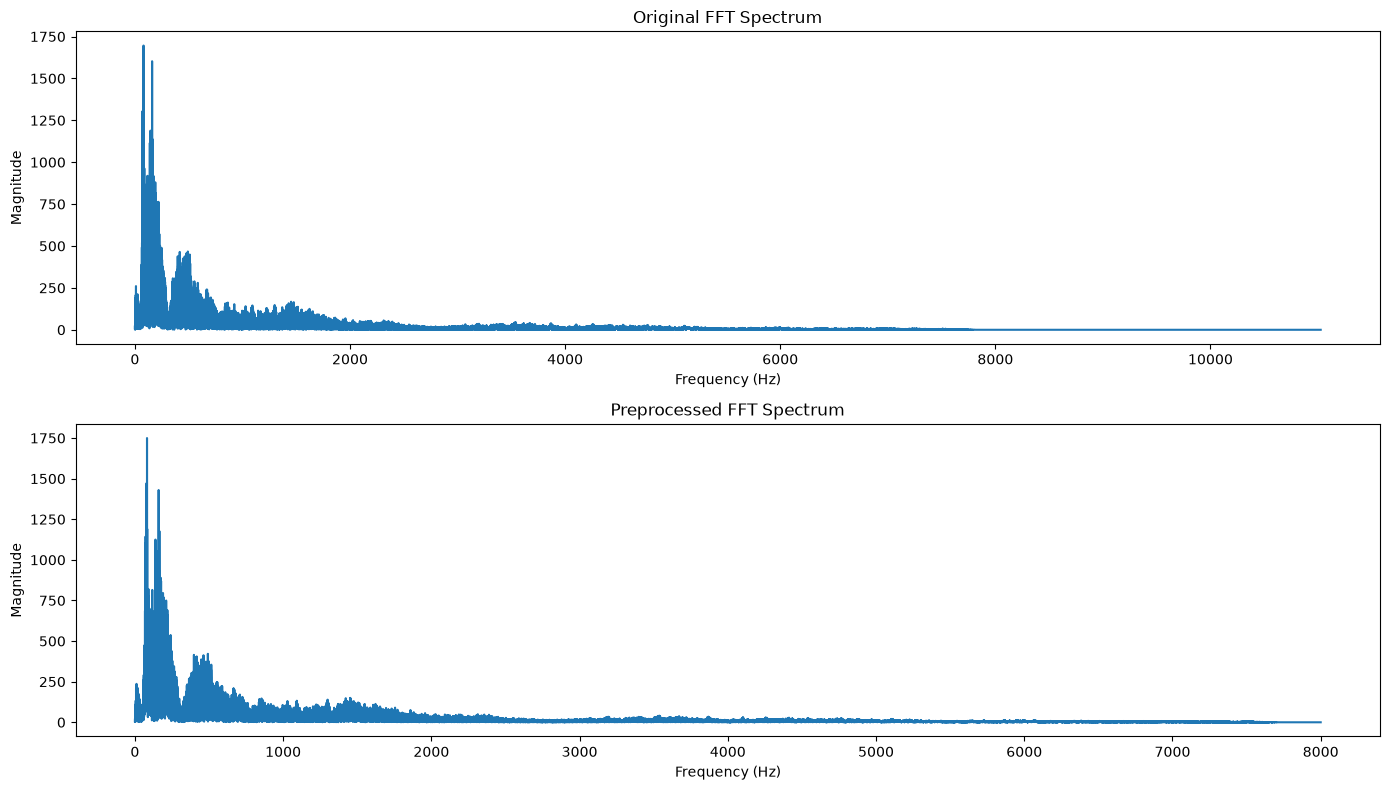

In [8]:
fft_original = np.abs(np.fft.rfft(audio))
freq_original = np.fft.rfftfreq(len(audio), 1/sr)

fft_processed = np.abs(np.fft.rfft(audio_processed))
freq_processed = np.fft.rfftfreq(len(audio_processed), 1/new_sr)

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
plt.plot(freq_original, fft_original)
plt.title("Original FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.subplot(2,1,2)
plt.plot(freq_processed, fft_processed)
plt.title("Preprocessed FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()